Library berhasil diimport.
Konfigurasi: WM_SIZE=64, SEED=99, QF=[10, 20, 30, 50, 70, 90, 100]
Upload foto wajah kamu:


Saving photo.jpeg to photo (1).jpeg
Foto dimuat: photo (1).jpeg
Ukuran (tinggi x lebar): (2080, 1170)
Nilai piksel - min: 0, max: 255, rata-rata: 166.1


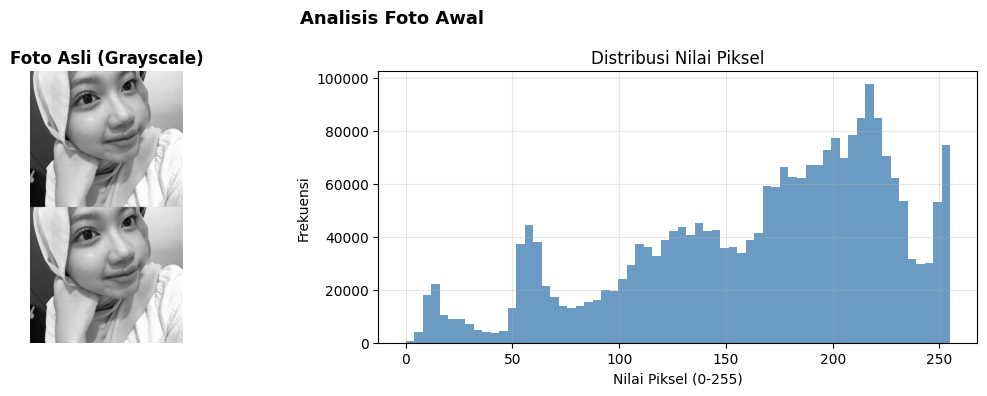

Watermark berhasil dibuat
Ukuran  : (64, 64)
Jumlah bit 0 : 2049 (50.0%)
Jumlah bit 1 : 2047 (50.0%)


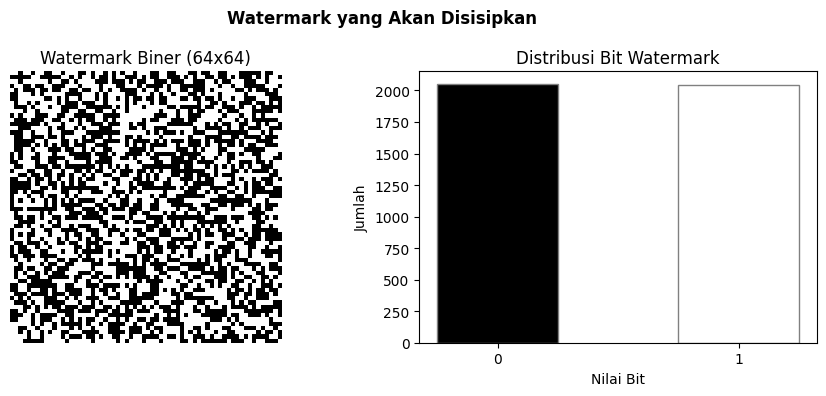

Perbedaan piksel maksimal : 1 (hanya 1 bit!)
Jumlah piksel yang berubah: 2039
Total piksel              : 2433600


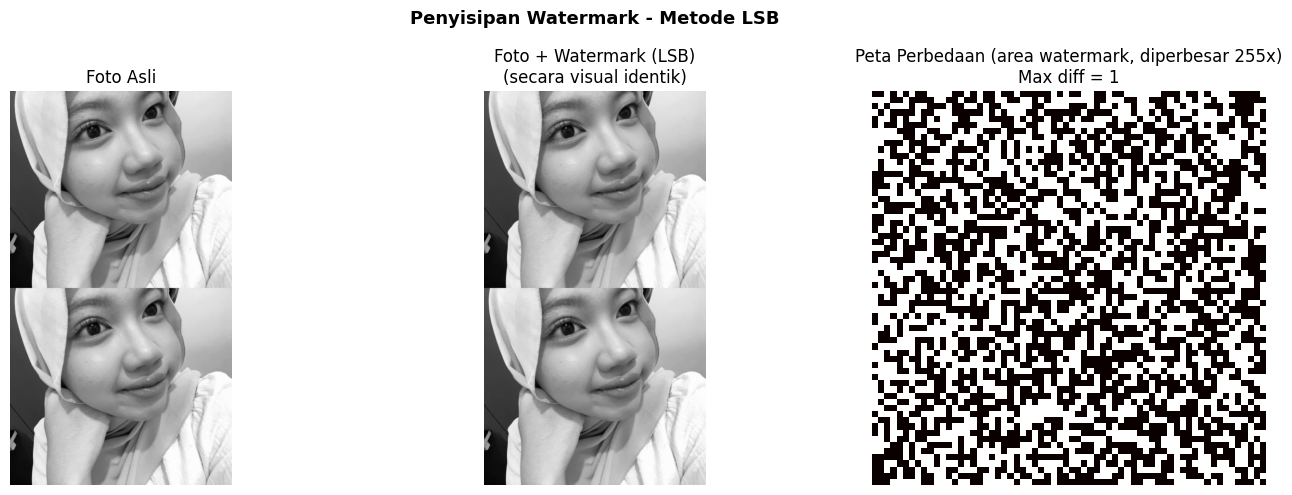

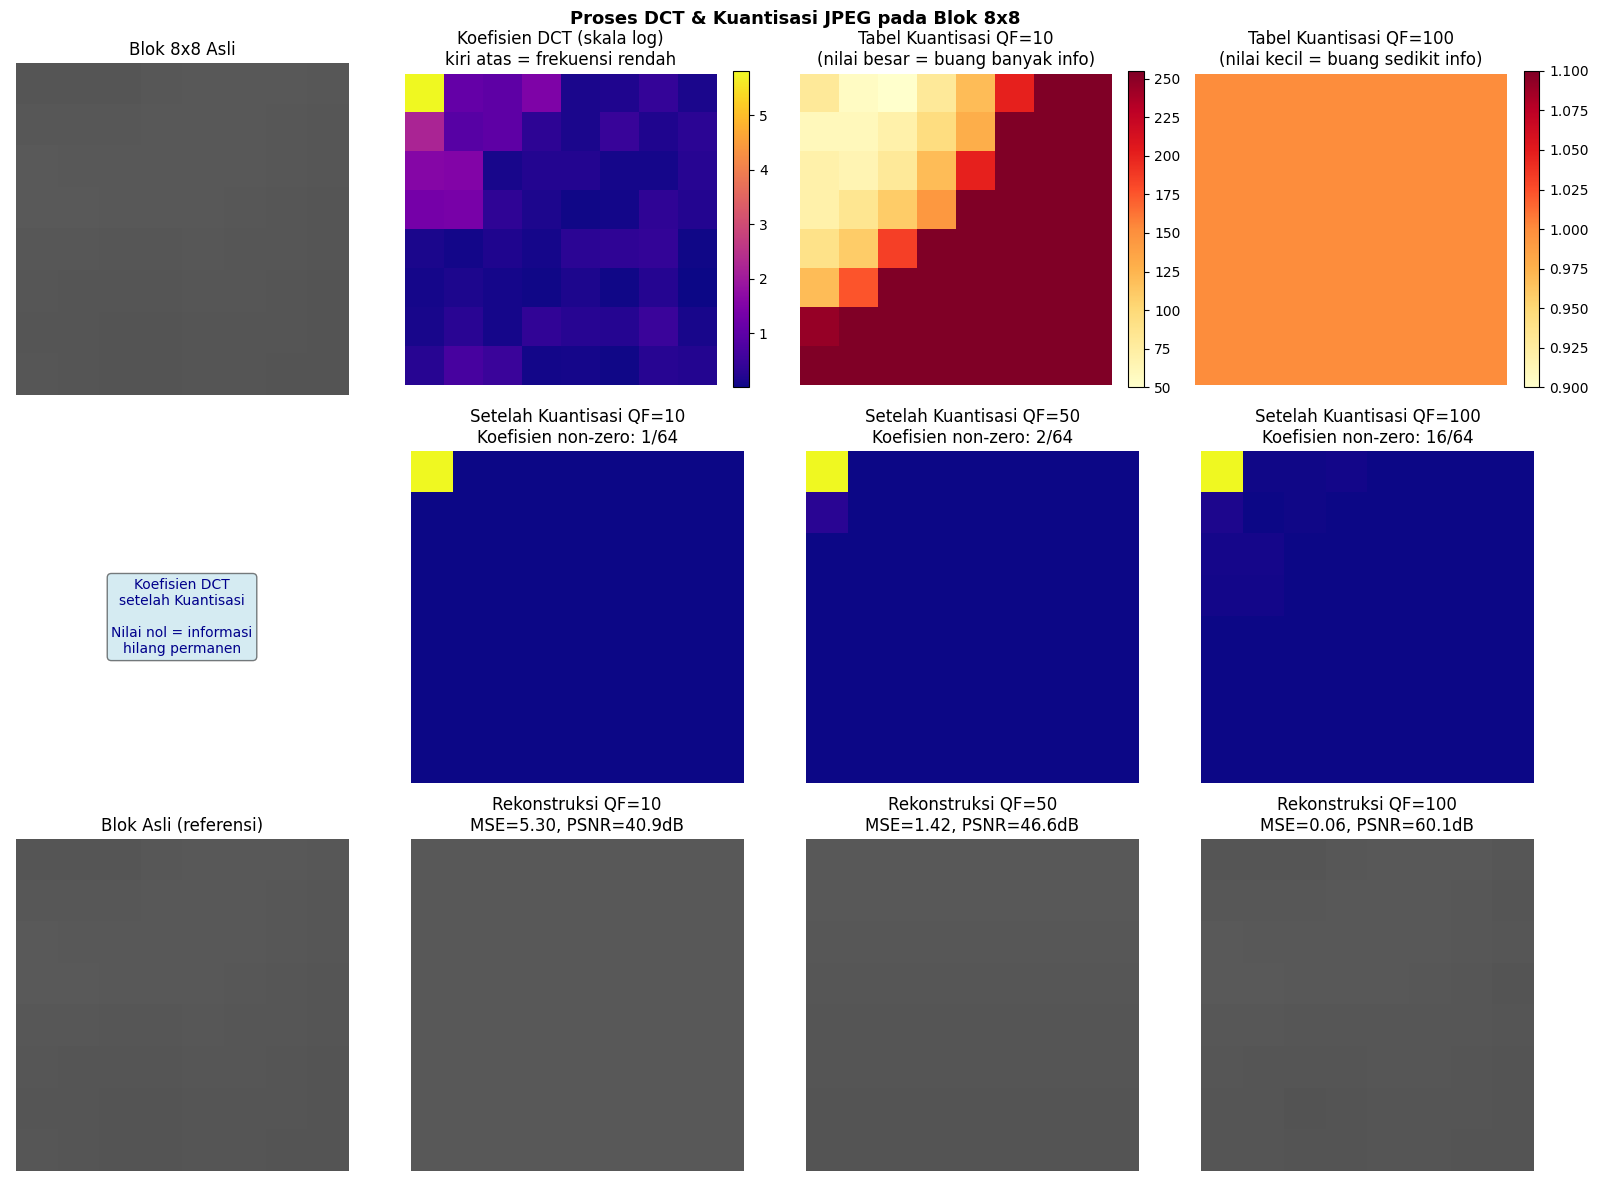

Semakin rendah QF, semakin banyak koefisien DCT yang di-nol-kan -> LSB ikut rusak.
Ukuran file asli (PNG): 705.0 KB

QF     Ukuran (KB)    Rasio Kompresi   Penghematan
-------------------------------------------------------
QF=10   42.0           16.8            x 94.0% lebih kecil
QF=20   55.4           12.7            x 92.1% lebih kecil
QF=30   68.5           10.3            x 90.3% lebih kecil
QF=50   91.0           7.7             x 87.1% lebih kecil
QF=70   124.8          5.6             x 82.3% lebih kecil
QF=90   230.9          3.1             x 67.2% lebih kecil
QF=100  565.1          1.2             x 19.8% lebih kecil


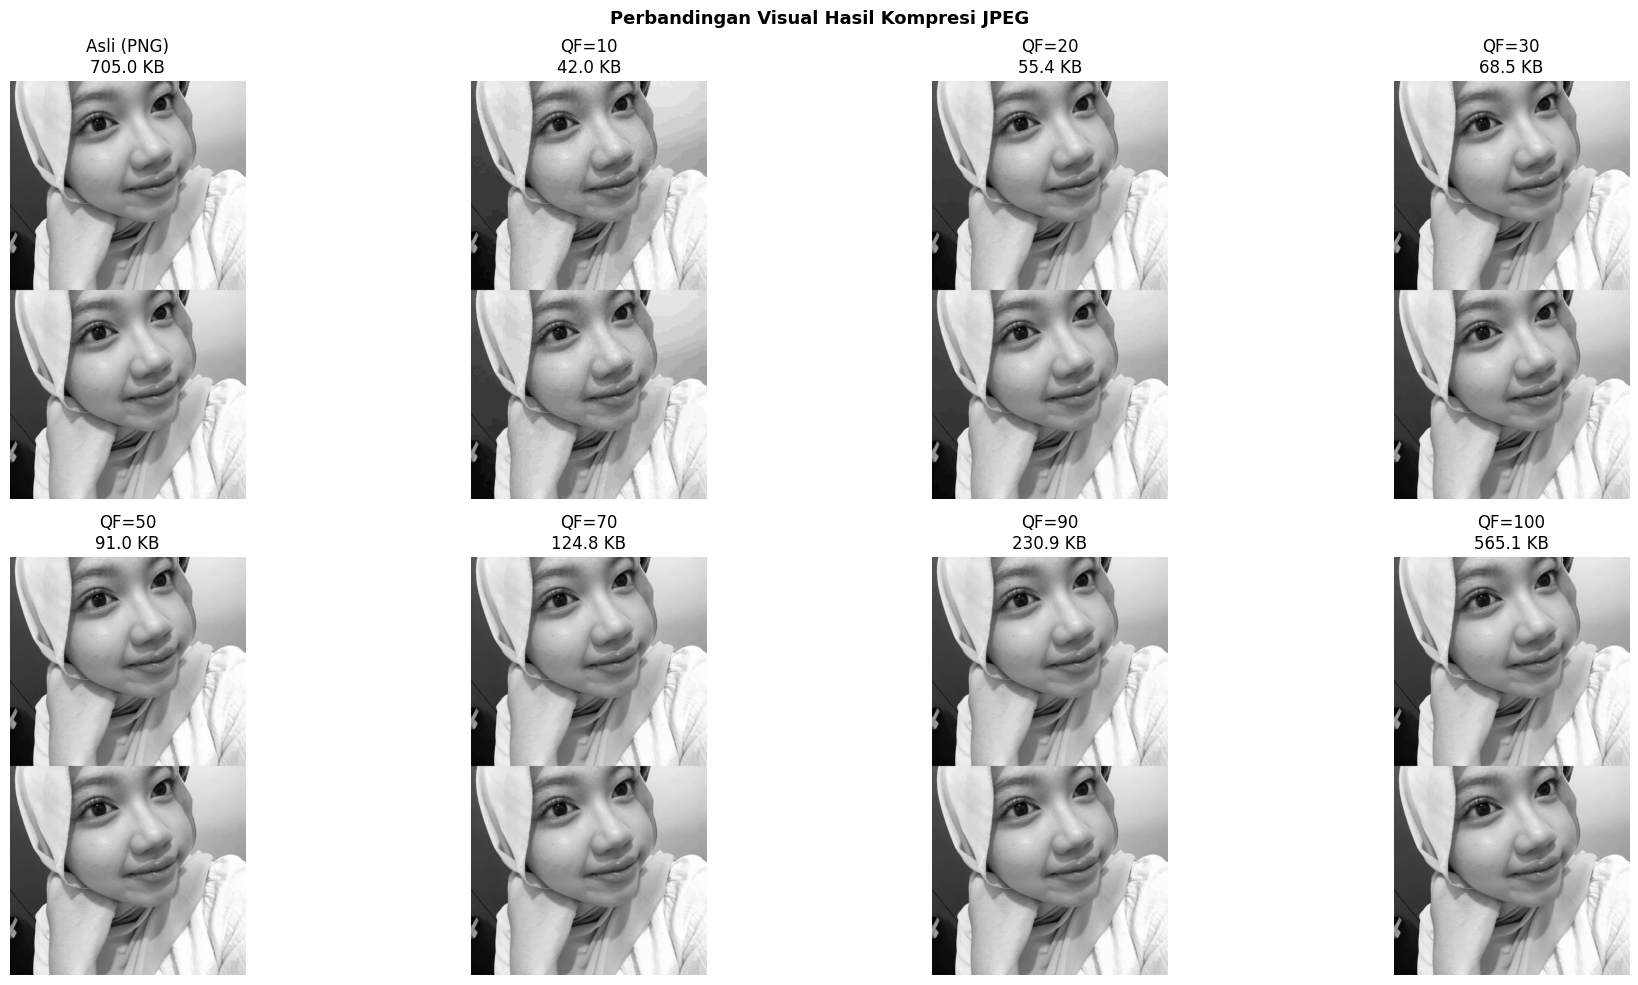

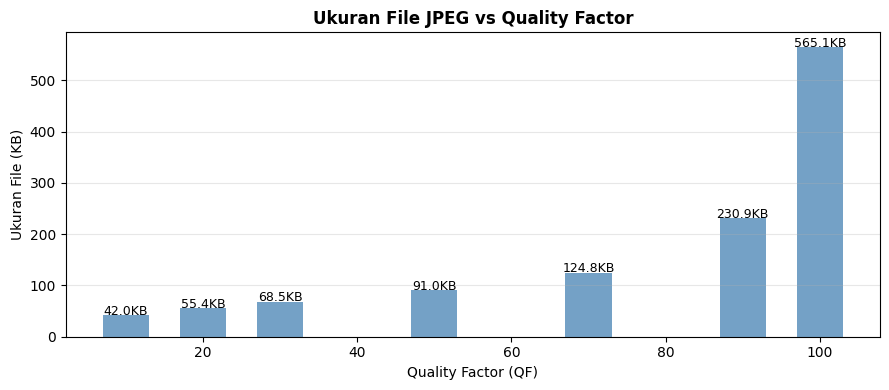

===== HASIL EVALUASI =====
QF     BER        PSNR (dB)    Status
----------------------------------------------------
QF=10   BER=0.5027   PSNR= 35.38 dB   TIDAK bisa diekstrak
QF=20   BER=0.5063   PSNR= 39.45 dB   TIDAK bisa diekstrak
QF=30   BER=0.5010   PSNR= 41.56 dB   TIDAK bisa diekstrak
QF=50   BER=0.4934   PSNR= 44.19 dB   TIDAK bisa diekstrak
QF=70   BER=0.4932   PSNR= 46.69 dB   TIDAK bisa diekstrak
QF=90   BER=0.4827   PSNR= 55.32 dB   TIDAK bisa diekstrak
QF=100  BER=0.0908   PSNR= 61.45 dB   BISA diekstrak


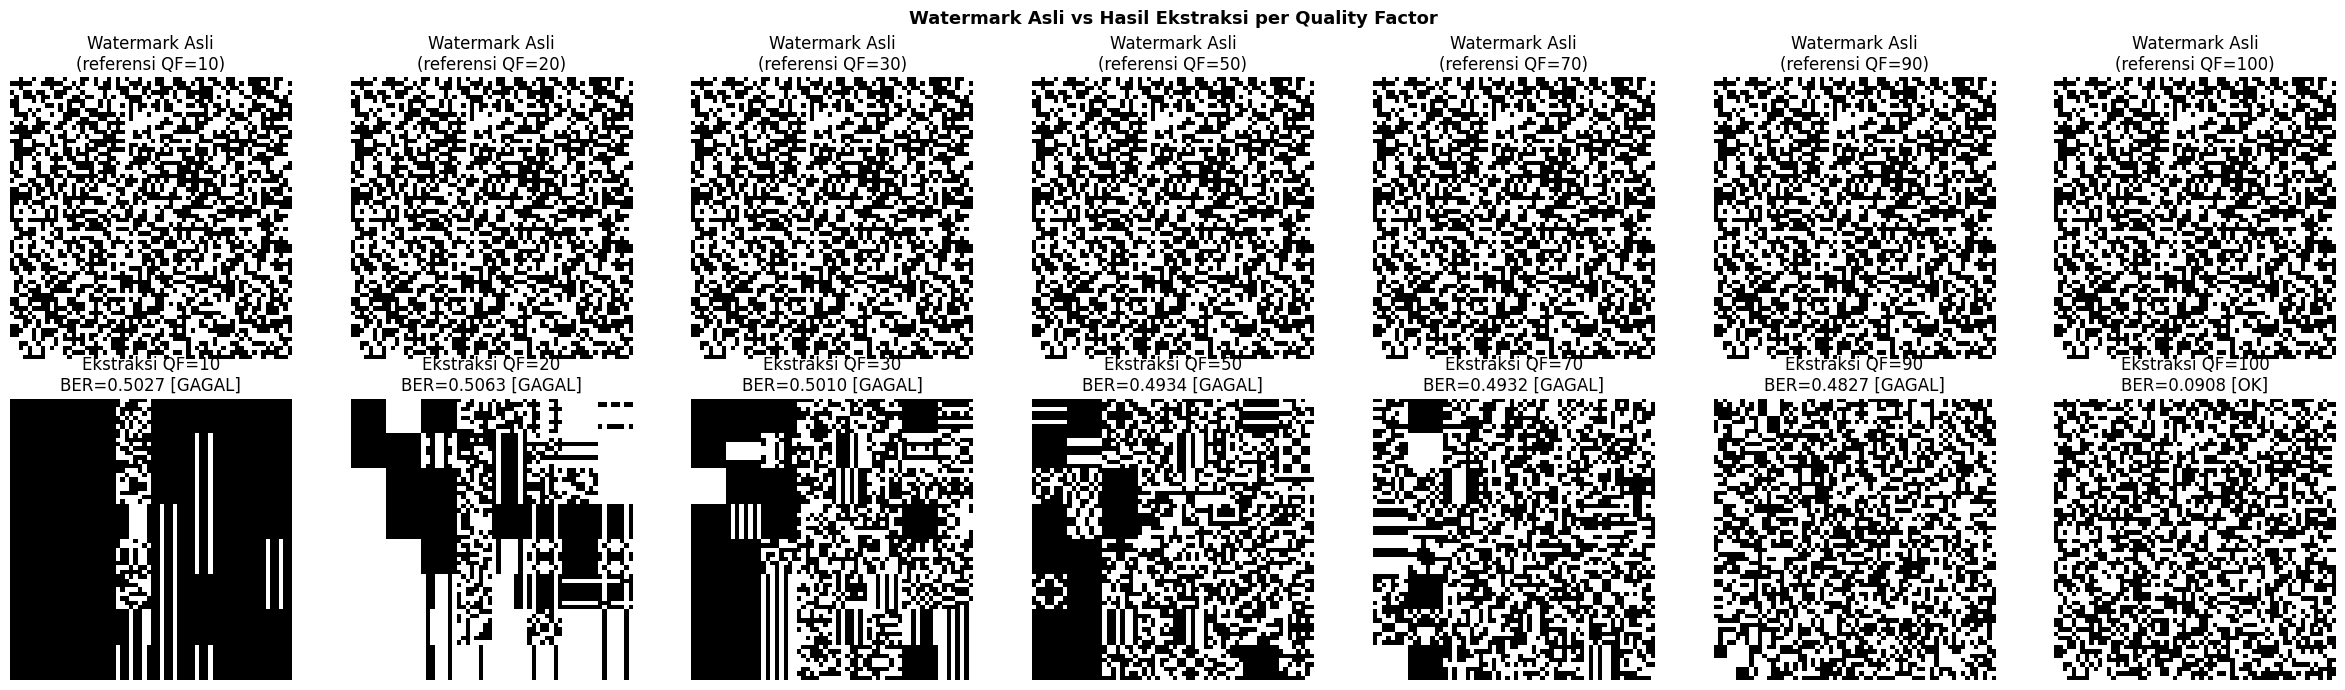

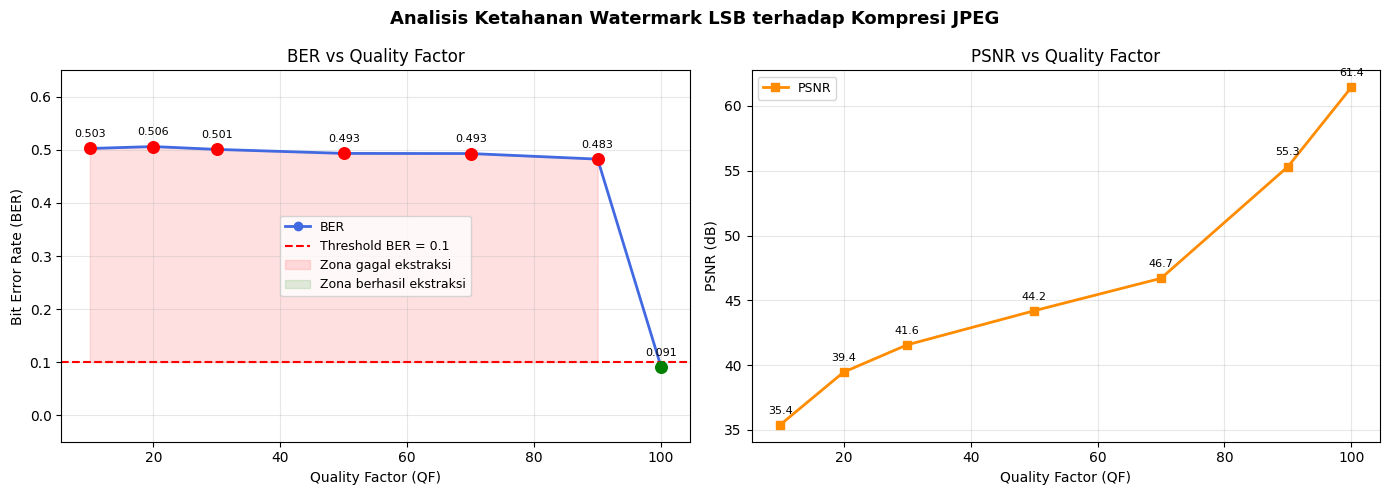

   KESIMPULAN EVALUASI WATERMARKING LSB

QF yang watermark-nya BISA diekstrak  : [100]
QF yang watermark-nya TIDAK bisa      : [10, 20, 30, 50, 70, 90]

Detail:
  QF=10   | BER=0.5027 | PSNR=35.38 dB | GAGAL
  QF=20   | BER=0.5063 | PSNR=39.45 dB | GAGAL
  QF=30   | BER=0.5010 | PSNR=41.56 dB | GAGAL
  QF=50   | BER=0.4934 | PSNR=44.19 dB | GAGAL
  QF=70   | BER=0.4932 | PSNR=46.69 dB | GAGAL
  QF=90   | BER=0.4827 | PSNR=55.32 dB | GAGAL
  QF=100  | BER=0.0908 | PSNR=61.45 dB | BISA

Analisis:
- Metode LSB menyisipkan watermark di bit ke-0 (LSB) setiap piksel.
- Kompresi JPEG bersifat lossy: koefisien DCT frekuensi tinggi dibuang
  saat kuantisasi, yang mengubah nilai piksel secara acak termasuk LSB-nya.
- Akibatnya, pada QF rendah (10-90), BER mendekati 0.5 yang berarti
  watermark hancur total (setara tebakan acak).
- Hanya pada QF=100 (hampir lossless) watermark masih bisa diekstrak
  karena perubahan piksel sangat minimal.
- Kesimpulan: LSB watermarking TIDAK tahan terhadap kompre

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: wajah_watermarked.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: hasil_watermarking.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: grafik_ber_psnr.png


In [2]:
%matplotlib inline

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.fftpack import dct, idct
import os
from google.colab import files

# --- Parameter global ---
WM_SIZE       = 64          # ukuran watermark (64x64 piksel)
RANDOM_SEED   = 99          # seed untuk reprodusibilitas
QF_LIST       = [10, 20, 30, 50, 70, 90, 100]  # variasi quality factor JPEG
BER_THRESHOLD = 0.1         # batas BER: di bawah ini = watermark masih bisa diekstrak

print('Library berhasil diimport.')
print(f'Konfigurasi: WM_SIZE={WM_SIZE}, SEED={RANDOM_SEED}, QF={QF_LIST}')

print('Upload foto wajah kamu:')
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Load sebagai grayscale
img_pil   = Image.open(filename).convert('L')
img_array = np.array(img_pil, dtype=np.uint8)

print(f'Foto dimuat: {filename}')
print(f'Ukuran (tinggi x lebar): {img_array.shape}')
print(f'Nilai piksel - min: {img_array.min()}, max: {img_array.max()}, rata-rata: {img_array.mean():.1f}')

# Tampilkan histogram & foto
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.imshow(img_array, cmap='gray')
ax1.set_title('Foto Asli (Grayscale)', fontweight='bold')
ax1.axis('off')

ax2.hist(img_array.ravel(), bins=64, color='steelblue', alpha=0.8)
ax2.set_title('Distribusi Nilai Piksel')
ax2.set_xlabel('Nilai Piksel (0-255)')
ax2.set_ylabel('Frekuensi')
ax2.grid(True, alpha=0.3)

plt.suptitle('Analisis Foto Awal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

rng       = np.random.default_rng(RANDOM_SEED)
watermark = rng.integers(0, 2, size=(WM_SIZE, WM_SIZE), dtype=np.uint8)

print(f'Watermark berhasil dibuat')
print(f'Ukuran  : {watermark.shape}')
print(f'Jumlah bit 0 : {np.sum(watermark == 0)} ({np.sum(watermark==0)/watermark.size*100:.1f}%)')
print(f'Jumlah bit 1 : {np.sum(watermark == 1)} ({np.sum(watermark==1)/watermark.size*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].imshow(watermark, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Watermark Biner (64x64)')
axes[0].axis('off')

bit0 = np.sum(watermark == 0)
bit1 = np.sum(watermark == 1)
axes[1].bar([0, 1], [bit0, bit1], color=['black', 'white'],
            edgecolor='gray', width=0.5)
axes[1].set_xticks([0, 1])
axes[1].set_title('Distribusi Bit Watermark')
axes[1].set_xlabel('Nilai Bit')
axes[1].set_ylabel('Jumlah')

plt.suptitle('Watermark yang Akan Disisipkan', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Sisipkan watermark ke sudut kiri atas gambar
img_wm = img_array.copy()
img_wm[:WM_SIZE, :WM_SIZE] = (img_wm[:WM_SIZE, :WM_SIZE] & 0b11111110) | watermark

# Simpan hasil
img_wm_pil = Image.fromarray(img_wm)
img_wm_pil.save('wajah_watermarked.png')

# Hitung perbedaan
diff = np.abs(img_array.astype(int) - img_wm.astype(int))
print(f'Perbedaan piksel maksimal : {diff.max()} (hanya 1 bit!)')
print(f'Jumlah piksel yang berubah: {np.sum(diff > 0)}')
print(f'Total piksel              : {img_array.size}')

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_array, cmap='gray')
axes[0].set_title('Foto Asli')
axes[0].axis('off')

axes[1].imshow(img_wm, cmap='gray')
axes[1].set_title('Foto + Watermark (LSB)\n(secara visual identik)')
axes[1].axis('off')

# Diff diperbesar supaya kelihatan
axes[2].imshow(diff[:WM_SIZE, :WM_SIZE] * 255, cmap='hot')
axes[2].set_title(f'Peta Perbedaan (area watermark, diperbesar 255x)\nMax diff = {diff.max()}')
axes[2].axis('off')

plt.suptitle('Penyisipan Watermark - Metode LSB', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Ambil satu blok 8x8 dari area watermark
block = img_array[:8, :8].astype(float) - 128  # level shift

def dct2(b):
    return dct(dct(b.T, norm='ortho').T, norm='ortho')

def idct2(b):
    return idct(idct(b.T, norm='ortho').T, norm='ortho')

def buat_tabel_kuantisasi(qf):
    """Buat tabel kuantisasi JPEG standar berdasarkan Quality Factor."""
    tabel_dasar = np.array([
        [16,11,10,16,24,40,51,61],
        [12,12,14,19,26,58,60,55],
        [14,13,16,24,40,57,69,56],
        [14,17,22,29,51,87,80,62],
        [18,22,37,56,68,109,103,77],
        [24,35,55,64,81,104,113,92],
        [49,64,78,87,103,121,120,101],
        [72,92,95,98,112,100,103,99]
    ], dtype=float)
    skala = 5000 / qf if qf < 50 else 200 - 2 * qf
    tabel = np.floor((tabel_dasar * skala + 50) / 100)
    return np.clip(tabel, 1, 255)

dct_block = dct2(block)

# Visualisasi DCT & kuantisasi
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Proses DCT & Kuantisasi JPEG pada Blok 8x8', fontsize=13, fontweight='bold')

# Baris 1: blok asli, koefisien DCT, tabel kuantisasi QF=10 & QF=100
axes[0,0].imshow(block + 128, cmap='gray', vmin=0, vmax=255)
axes[0,0].set_title('Blok 8x8 Asli')
axes[0,0].axis('off')

im = axes[0,1].imshow(np.log(np.abs(dct_block) + 1), cmap='plasma')
axes[0,1].set_title('Koefisien DCT (skala log)\nkiri atas = frekuensi rendah')
axes[0,1].axis('off')
plt.colorbar(im, ax=axes[0,1], fraction=0.046)

im2 = axes[0,2].imshow(buat_tabel_kuantisasi(10), cmap='YlOrRd')
axes[0,2].set_title('Tabel Kuantisasi QF=10\n(nilai besar = buang banyak info)')
axes[0,2].axis('off')
plt.colorbar(im2, ax=axes[0,2], fraction=0.046)

im3 = axes[0,3].imshow(buat_tabel_kuantisasi(100), cmap='YlOrRd')
axes[0,3].set_title('Tabel Kuantisasi QF=100\n(nilai kecil = buang sedikit info)')
axes[0,3].axis('off')
plt.colorbar(im3, ax=axes[0,3], fraction=0.046)

# Baris 2: koefisien setelah dikuantisasi
axes[1,0].axis('off')
axes[1,0].text(0.5, 0.5,
    'Koefisien DCT\nsetelah Kuantisasi\n\nNilai nol = informasi\nhilang permanen',
    ha='center', va='center', fontsize=10, color='darkblue',
    transform=axes[1,0].transAxes,
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

for col, qf in enumerate([10, 50, 100]):
    q = buat_tabel_kuantisasi(qf)
    quantized = np.round(dct_block / q)
    nonzero = np.count_nonzero(quantized)
    axes[1, col+1].imshow(np.abs(quantized), cmap='plasma')
    axes[1, col+1].set_title(f'Setelah Kuantisasi QF={qf}\nKoefisien non-zero: {nonzero}/64')
    axes[1, col+1].axis('off')

# Baris 3: rekonstruksi blok
axes[2,0].imshow(block + 128, cmap='gray', vmin=0, vmax=255)
axes[2,0].set_title('Blok Asli (referensi)')
axes[2,0].axis('off')

for col, qf in enumerate([10, 50, 100]):
    q = buat_tabel_kuantisasi(qf)
    quantized = np.round(dct_block / q)
    rekonstruksi = np.clip(idct2(quantized * q) + 128, 0, 255)
    mse = np.mean((block + 128 - rekonstruksi) ** 2)
    psnr_blok = 10 * np.log10(255**2 / mse) if mse > 0 else float('inf')
    axes[2, col+1].imshow(rekonstruksi, cmap='gray', vmin=0, vmax=255)
    axes[2, col+1].set_title(f'Rekonstruksi QF={qf}\nMSE={mse:.2f}, PSNR={psnr_blok:.1f}dB')
    axes[2, col+1].axis('off')

plt.tight_layout()
plt.savefig('visualisasi_dct.png', dpi=150, bbox_inches='tight')
plt.show()
print('Semakin rendah QF, semakin banyak koefisien DCT yang di-nol-kan -> LSB ikut rusak.')

ukuran_asli = os.path.getsize('wajah_watermarked.png')
ukuran_file = []

print(f'Ukuran file asli (PNG): {ukuran_asli/1024:.1f} KB')
print()
print(f'{"QF":<6} {"Ukuran (KB)":<14} {"Rasio Kompresi":<16} {"Penghematan"}')
print('-' * 55)

for qf in QF_LIST:
    path = f'wajah_qf{qf}.jpg'
    img_wm_pil.save(path, 'JPEG', quality=qf)
    size = os.path.getsize(path)
    ukuran_file.append(size)
    rasio = ukuran_asli / size
    hemat = (1 - size/ukuran_asli) * 100
    print(f'QF={qf:<4} {size/1024:<14.1f} {rasio:<16.1f}x {hemat:.1f}% lebih kecil')

# Tampilkan semua hasil kompresi
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Perbandingan Visual Hasil Kompresi JPEG', fontsize=13, fontweight='bold')

# Foto asli di posisi pertama
axes[0, 0].imshow(img_wm, cmap='gray')
axes[0, 0].set_title(f'Asli (PNG)\n{ukuran_asli/1024:.1f} KB')
axes[0, 0].axis('off')

for i, qf in enumerate(QF_LIST):
    row, col = divmod(i + 1, 4)
    img_qf = np.array(Image.open(f'wajah_qf{qf}.jpg').convert('L'))
    axes[row, col].imshow(img_qf, cmap='gray')
    axes[row, col].set_title(f'QF={qf}\n{ukuran_file[i]/1024:.1f} KB')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Grafik ukuran file
plt.figure(figsize=(9, 4))
bars = plt.bar(QF_LIST, [s/1024 for s in ukuran_file], color='steelblue', alpha=0.75, width=6)
for bar, size in zip(bars, ukuran_file):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{size/1024:.1f}KB', ha='center', fontsize=9)
plt.title('Ukuran File JPEG vs Quality Factor', fontweight='bold')
plt.xlabel('Quality Factor (QF)')
plt.ylabel('Ukuran File (KB)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

def ekstrak_watermark(path, ukuran=(64, 64)):
    """Ekstrak watermark dari LSB gambar."""
    arr = np.array(Image.open(path).convert('L'), dtype=np.uint8)
    h, w = ukuran
    return arr[:h, :w] & 1

def hitung_ber(wm_asli, wm_ekstrak):
    """Bit Error Rate: proporsi bit yang salah."""
    return float(np.sum(wm_asli != wm_ekstrak)) / wm_asli.size

def hitung_psnr(img_asli, img_kompresi):
    """Peak Signal-to-Noise Ratio dalam dB."""
    mse = np.mean((img_asli.astype(np.float64) - img_kompresi.astype(np.float64))**2)
    return float('inf') if mse == 0 else 10 * np.log10(255**2 / mse)

print('===== HASIL EVALUASI =====')
print(f'{"QF":<6} {"BER":<10} {"PSNR (dB)":<12} {"Status"}')
print('-' * 52)

ber_values  = []
psnr_values = []

for qf in QF_LIST:
    path       = f'wajah_qf{qf}.jpg'
    wm_ekstrak = ekstrak_watermark(path)
    arr_kompr  = np.array(Image.open(path).convert('L'))

    ber_val  = hitung_ber(watermark, wm_ekstrak)
    psnr_val = hitung_psnr(img_array, arr_kompr)

    ber_values.append(ber_val)
    psnr_values.append(psnr_val)

    status = 'BISA diekstrak' if ber_val < BER_THRESHOLD else 'TIDAK bisa diekstrak'
    print(f'QF={qf:<4} BER={ber_val:.4f}   PSNR={psnr_val:6.2f} dB   {status}')

# Visualisasi watermark asli vs hasil ekstraksi
fig, axes = plt.subplots(2, len(QF_LIST), figsize=(24, 7))
fig.suptitle('Watermark Asli vs Hasil Ekstraksi per Quality Factor', fontsize=13, fontweight='bold')

for i, qf in enumerate(QF_LIST):
    axes[0, i].imshow(watermark, cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'Watermark Asli\n(referensi QF={qf})')
    axes[0, i].axis('off')

    wm_e = ekstrak_watermark(f'wajah_qf{qf}.jpg')
    ber_v = hitung_ber(watermark, wm_e)
    status = 'OK' if ber_v < BER_THRESHOLD else 'GAGAL'
    axes[1, i].imshow(wm_e, cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f'Ekstraksi QF={qf}\nBER={ber_v:.4f} [{status}]')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('hasil_watermarking.png', dpi=150, bbox_inches='tight')
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analisis Ketahanan Watermark LSB terhadap Kompresi JPEG',
             fontsize=13, fontweight='bold')

# --- Grafik BER ---
ax1.plot(QF_LIST, ber_values, marker='o', color='royalblue', linewidth=2, label='BER')
ax1.axhline(y=BER_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
            label=f'Threshold BER = {BER_THRESHOLD}')
ax1.fill_between(QF_LIST, ber_values, BER_THRESHOLD,
                 where=[b > BER_THRESHOLD for b in ber_values],
                 alpha=0.12, color='red', label='Zona gagal ekstraksi')
ax1.fill_between(QF_LIST, ber_values, BER_THRESHOLD,
                 where=[b <= BER_THRESHOLD for b in ber_values],
                 alpha=0.12, color='green', label='Zona berhasil ekstraksi')
for qf, bv in zip(QF_LIST, ber_values):
    color = 'green' if bv < BER_THRESHOLD else 'red'
    ax1.scatter(qf, bv, color=color, zorder=5, s=70)
    ax1.annotate(f'{bv:.3f}', (qf, bv), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=8)
ax1.set_title('BER vs Quality Factor')
ax1.set_xlabel('Quality Factor (QF)')
ax1.set_ylabel('Bit Error Rate (BER)')
ax1.set_ylim(-0.05, 0.65)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Grafik PSNR ---
ax2.plot(QF_LIST, psnr_values, marker='s', color='darkorange', linewidth=2, label='PSNR')
for qf, pv in zip(QF_LIST, psnr_values):
    ax2.annotate(f'{pv:.1f}', (qf, pv), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=8)
ax2.set_title('PSNR vs Quality Factor')
ax2.set_xlabel('Quality Factor (QF)')
ax2.set_ylabel('PSNR (dB)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('grafik_ber_psnr.png', dpi=150, bbox_inches='tight')
plt.show()

print('=' * 55)
print('   KESIMPULAN EVALUASI WATERMARKING LSB')
print('=' * 55)

qf_berhasil = [qf for qf, bv in zip(QF_LIST, ber_values) if bv < BER_THRESHOLD]
qf_gagal    = [qf for qf, bv in zip(QF_LIST, ber_values) if bv >= BER_THRESHOLD]

print(f'\nQF yang watermark-nya BISA diekstrak  : {qf_berhasil}')
print(f'QF yang watermark-nya TIDAK bisa      : {qf_gagal}')
print(f'\nDetail:')
for qf, bv, pv in zip(QF_LIST, ber_values, psnr_values):
    status = 'BISA' if bv < BER_THRESHOLD else 'GAGAL'
    print(f'  QF={qf:<4} | BER={bv:.4f} | PSNR={pv:.2f} dB | {status}')

print(f'''
Analisis:
- Metode LSB menyisipkan watermark di bit ke-0 (LSB) setiap piksel.
- Kompresi JPEG bersifat lossy: koefisien DCT frekuensi tinggi dibuang
  saat kuantisasi, yang mengubah nilai piksel secara acak termasuk LSB-nya.
- Akibatnya, pada QF rendah (10-90), BER mendekati 0.5 yang berarti
  watermark hancur total (setara tebakan acak).
- Hanya pada QF=100 (hampir lossless) watermark masih bisa diekstrak
  karena perubahan piksel sangat minimal.
- Kesimpulan: LSB watermarking TIDAK tahan terhadap kompresi JPEG.
  Untuk ketahanan lebih baik, perlu metode yang lebih robust seperti
  DCT-domain watermarking atau DWT watermarking.
''')

output_files = [
    'wajah_watermarked.png',
    'visualisasi_dct.png',
    'hasil_watermarking.png',
    'grafik_ber_psnr.png'
]

for f in output_files:
    if os.path.exists(f):
        files.download(f)
        print(f'Downloaded: {f}')
    else:
        print(f'File tidak ditemukan: {f}')